Pandas is used for data manipulation and matplotlib is used for visualization, and scipy for statistical hypothesis testing.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

The dataset is loaded from a CSV file. The data uses semicolons as separators and commas as decimal points.

In [4]:
df = pd.read_csv("data.csv", sep=";", decimal=",")
df.head()

,day,screen_time,evening_screen,social_media,productivity_and_others,sleep,mood,stress,focus,productivity_level,evening_screen_ratio,social_media_ratio
0,1,7.25,3.0,5.25,2.00,7.5,4.0,3.0,2.0,4.05,0.41,0.72
1,2,5.75,2.0,3.50,2.00,8.5,4.0,3.0,3.0,4.85,0.35,0.61
2,3,4.75,1.5,2.75,2.00,9.0,3.0,4.0,4.0,5.30,0.32,0.58
3,4,8.75,2.0,5.00,3.75,8.0,3.0,4.0,1.0,3.50,0.23,0.57
4,5,5.75,1.5,3.25,2.50,8.0,3.0,5.0,4.0,5.00,0.26,0.57


Checking the dataset for missing values and correcting the data types.

In [5]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   day                      28 non-null     int64  
 1   screen_time              28 non-null     float64
 2   evening_screen           28 non-null     float64
 3   social_media             28 non-null     float64
 4   productivity_and_others  28 non-null     float64
 5   sleep                    28 non-null     float64
 6   mood                     28 non-null     float64
 7   stress                   28 non-null     float64
 8   focus                    28 non-null     float64
 9   productivity_level       28 non-null     float64
 10  evening_screen_ratio     28 non-null     float64
 11  social_media_ratio       28 non-null     float64
dtypes: float64(11), int64(1)
memory usage: 2.8 KB


,0
day,0
screen_time,0
evening_screen,0
social_media,0
productivity_and_others,0
sleep,0
mood,0
stress,0
focus,0
productivity_level,0


A productivity score is calculated using focus, sleep, and mood.
Ratios for evening screen usage and social media usage are also computed.

In [6]:
df["productivity_score"] = (
    df["focus"] * 0.5 +
    df["sleep"] * 0.3 +
    df["mood"] * 0.2
)

df["evening_screen_ratio"] = df["evening_screen"] / df["screen_time"]
df["social_media_ratio"] = df["social_media"] / df["screen_time"]

## Exploratary Data Analysis (EDA)
Basic descriptive statistics and distributions are examined
to understand the structure of the data.

In [7]:
df.describe()


,day,screen_time,evening_screen,social_media,productivity_and_others,sleep,mood,stress,focus,productivity_level,evening_screen_ratio,social_media_ratio,productivity_score
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,14.500000,5.892857,1.625000,3.866071,2.017857,7.875000,3.821429,3.785714,3.714286,4.983929,0.272526,0.649394,4.983929
std,8.225975,1.347887,0.702179,1.236936,0.690305,0.647288,0.818923,0.994695,1.181874,0.604314,0.088213,0.113295,0.604314
min,1.000000,3.750000,0.500000,1.750000,0.500000,7.000000,2.000000,1.000000,1.000000,3.500000,0.083333,0.461538,3.500000
25%,7.750000,5.000000,1.000000,3.000000,1.500000,7.500000,3.000000,3.000000,3.000000,4.700000,0.210714,0.569876,4.700000
50%,14.500000,5.750000,1.500000,3.500000,2.000000,8.000000,4.000000,4.000000,4.000000,5.050000,0.279221,0.651515,5.050000
75%,21.250000,6.625000,2.000000,5.000000,2.000000,8.500000,4.000000,4.250000,5.000000,5.312500,0.333333,0.732955,5.312500
max,28.000000,9.500000,3.500000,7.500000,3.750000,9.000000,5.000000,5.000000,5.000000,6.050000,0.454545,0.875000,6.050000


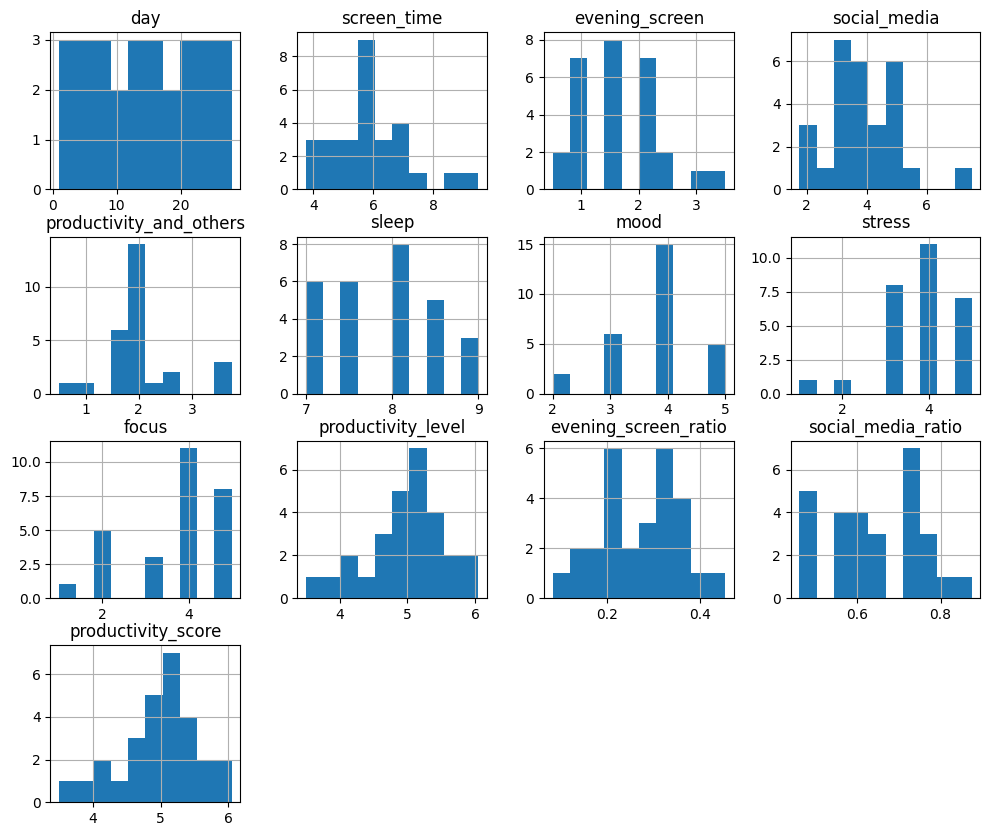

In [8]:
df.hist(figsize=(12,10))
plt.show()

## Hypothesis Testing
Pearson correlation is used to test the linear relationship between variables.
A significance level of 0.05 is used.

In [9]:
#H1:Evening screen time and sleep
corr, p = pearsonr(df["evening_screen"], df["sleep"])
decision = "Reject H0" if p < 0.05 else "Fail to reject H0"
corr, p, decision

(np.float64(0.21899760554846456),
 np.float64(0.2628622403324294),
 'Fail to reject H0')

Result for Hypothesis 1: The null hypothesis is not rejected, there is not enough statistical evidence to conclude that there is significant relationship between evening screen time and sleep duration.

In [10]:
#H2:Sleep and Productivity
corr, p = pearsonr(df["sleep"], df["productivity_score"])
decision = "Reject H0" if p < 0.05 else "Fail to reject H0"
corr, p, decision

(np.float64(0.0964592696326313),
 np.float64(0.6253481096979541),
 'Fail to reject H0')

Results for Hypothesis 2: The null hypothesis is not rejected. there is not enough statistical evidence to conclude that there is significant association between sleep duration and productivity score.

In [11]:
#H3:Evening screen ratio and focus
corr, p = pearsonr(df["evening_screen_ratio"], df["focus"])
decision = "Reject H0" if p < 0.05 else "Fail to reject H0"
corr, p, decision

(np.float64(0.016556618920394388),
 np.float64(0.9333580833247845),
 'Fail to reject H0')

Results for Hypothesis 3:The null hypothesis is not rejected. There is not enough statistical evidence to conclude that there is a significant relationship between evening screen ratio and focus level.

In [12]:
#H4:Social media ratio and stress
corr, p = pearsonr(df["social_media_ratio"], df["stress"])
decision = "Reject H0" if p < 0.05 else "Fail to reject H0"
corr, p, decision

(np.float64(-0.0057718847082713085),
 np.float64(0.9767452523362844),
 'Fail to reject H0')

Results for Hypothesis 4: The null hypothesis is not rejected. There is not enough statistical evidence to conclude that there is statistically significant association between social media usage and stress level.

## Conclusion
The analysis shows that screen usage patterns, especially in the evening
and on social media, are associated with sleep quality, focus, stress, and productivity. These findings can be used to improve daily routines.